# In Transformer implementation we used Encoder but here we need decoder

- Encoder -> can see all the data
- Decoder -> can see only previous data

In [22]:
import pandas as pd

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# import data

In [23]:
train_df = pd.read_csv(r"C:\Users\dhana\OneDrive\Desktop\Learning\AIML\Transformers\GPT Mini Project\TinyShakeSpeare\train.csv")
val_df = pd.read_csv(r"C:\Users\dhana\OneDrive\Desktop\Learning\AIML\Transformers\GPT Mini Project\TinyShakeSpeare\test.csv")


print(train_df.head())
print(train_df.columns)
print(train_df.shape)

                                                text
0  First Citizen:\nBefore we proceed any further,...
Index(['text'], dtype='str')
(1, 1)


In [24]:
train_text = train_df['text'][0]
val_text = val_df['text'][0]

print(train_text[:500])

print(len(train_text))

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
1003854


In [25]:
chars = sorted(list(set(train_text)))

print(chars)

size_vowels = len(chars)

print(size_vowels)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
65


# sting to int 

# int to string

In [26]:
# String to integer
stoi = {c:i for i,c in enumerate(chars)}

print(stoi)

# Integer to string
itos = {i:c for i,c in enumerate(chars)}

print(itos)

# if i give a word i will gave as list of int's
encode = lambda s: [stoi[c] for c in s]

# if i give a int sequence i will return word
decode = lambda l: ''.join([itos[i] for i in l])

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
{0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 34: 'V', 35: 'W', 36: 'X', 37: 'Y', 38: 'Z', 39: 'a', 40: 'b', 41: 'c', 42: 'd', 43: 'e', 44: 'f', 45: 'g', 46: 'h', 47: 'i',

# Check

In [27]:
print(encode("hello"))

test = encode("hello")

print(decode(test))

[46, 43, 50, 50, 53]
hello


# Converted the real data into tensors

In [28]:
train_data = torch.tensor(encode(train_text), dtype = torch.long)

print(train_data)
print(train_data.shape)


val_data = torch.tensor(encode(val_text), dtype = torch.long)

tensor([18, 47, 56,  ..., 43, 56, 43])
torch.Size([1003854])


# check

In [29]:
print("=====Train Data=====")

print("\nOriginal ", train_text[:20])

print("\nAfter Encode ", train_data[:20])

print("\nAfter Decode ", decode(train_data[:20].tolist()))

print("\n=====Val Data=====")

print("\nOriginal ", val_text[:20])

print("\nAfter Encode ", val_data[:20])

print("\nAfter Decode ", decode(val_data[:20].tolist()))

=====Train Data=====

Original  First Citizen:
Befor

After Encode  tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56])

After Decode  First Citizen:
Befor

=====Val Data=====

Original  rance ta'en
As shall

After Encode  tensor([56, 39, 52, 41, 43,  1, 58, 39,  5, 43, 52,  0, 13, 57,  1, 57, 46, 39,
        50, 50])

After Decode  rance ta'en
As shall


# Hyper Parameters

In [30]:
batch_size = 32

block_size = 64

n_embd = 128

n_head = 4

n_layer = 4

dropout = 0.2

learning_rate = 3e-4

max_iters = 5000

# Batch Loader

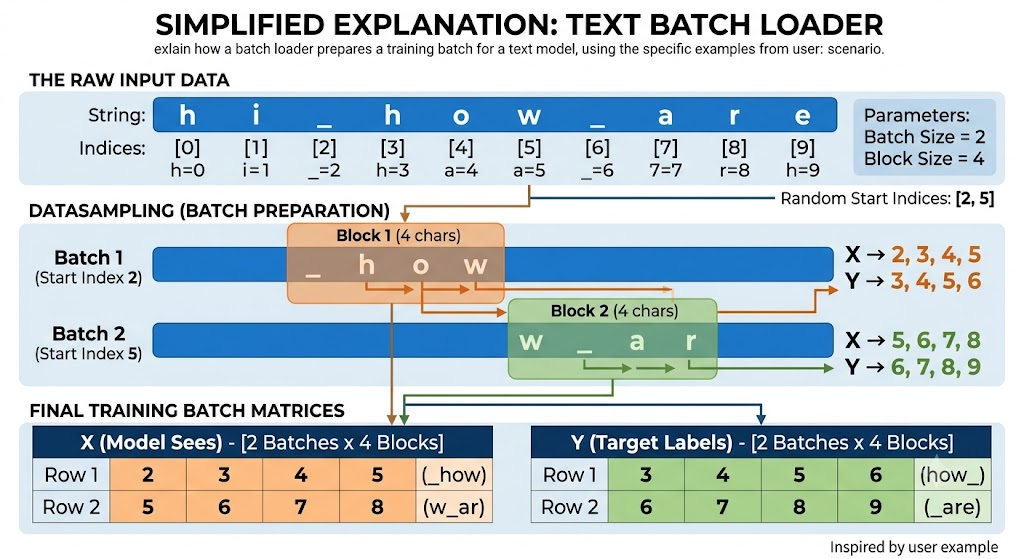

In [31]:
def get_data(split):

    data = (train_data if split == "train" else val_data)

    # random int from 0 to n
    ix = torch.randint(
        high = len(data) - block_size, # 0 to 1003854-64 (n)
        size = (batch_size,) # 32, 1
        )
    # output -> 32 random numbers

    # same as numpy stack
    x = torch.stack([
        data[i : i + block_size] # slicing
        for i in ix # iterating each element in ix
    ])

    y = torch.stack([
        data[i+1 : i + block_size + 1] # slicing with extra 1 increement
        for i in ix # iterating each element in ix
    ])

    return x, y


In [32]:
x, y = get_data("train")

print(x.shape)

print(y.shape)

torch.Size([32, 64])
torch.Size([32, 64])


# Check

In [33]:
sample_x = x[0]

sample_y = y[0]

print("=====x=====")
print(decode(sample_x.tolist()))

print("\n=====y=====")
print(decode(sample_y.tolist()))

=====x=====
rom thee every day in the hour,
For in a minute there are many d

=====y=====
om thee every day in the hour,
For in a minute there are many da


# Single Attention Head

In [34]:
class Head(nn.Module):
    
    def __init__(self, num_heads):

        super().__init__()

        self.query = nn.Linear(
            in_features = n_embd,
            out_features = num_heads,
            bias = False
        )

        self.key = nn.Linear(
            in_features = n_embd,
            out_features = num_heads,
            bias = False
        )

        self.value = nn.Linear(
            in_features = n_embd,
            out_features = num_heads,
            bias = False
        )

        self.register_buffer( # save it in buffer
            "tril", 
            torch.tril( # this trial convert the matrix in to a left skewed tringle and others will be 0 
                torch.ones(block_size, block_size) # create's a 64x64 ones matrix
            )
        )

        self.dropout = nn.Dropout(dropout) # Stops overfitting
    
    def forward(self, x):

        B, T, C = x.shape

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        weight = Q @ K.transpose(-2, -1) / math.sqrt(K.shape[-1])

        # Masked
        weight = weight.masked_fill(
            self.tril[:T,:T] == 0, # using the tril here so we are masking the future words using traingular matrix check below for ex
            float("-inf")
        )

        weight = F.softmax(weight, dim = -1)

        weight = self.dropout(weight)

        output = weight @ V

        return output
    

In [35]:
# weight

# The   cat   sat   down
# The   [ 2.1,  3.4, -1.2,  0.5]
# cat   [ 0.8,  1.1,  4.2, -0.9]
# sat   [-0.5,  2.2,  1.5,  3.1]
# down  [ 1.0, -0.1,  0.4,  2.8]  

# Masked

# The   cat   sat   down
# The   [ 2.1, -inf, -inf, -inf]
# cat   [ 0.8,  1.1, -inf, -inf]
# sat   [-0.5,  2.2,  1.5, -inf]
# down  [ 1.0, -0.1,  0.4,  2.8]  

# After Softmax

# The   cat   sat   down
# The   [100%,   0%,   0%,   0%]
# cat   [ 40%,  60%,   0%,   0%]
# sat   [  5%,  80%,  15%,   0%]
# down  [ 10%,   5%,  15%,  70%]

# Multi Head Attention

In [36]:
class MultiHeadAttention(nn.Module):

    def __init__(self, head_size, num_heads):

        super().__init__()

        self.heads = nn.ModuleList(
            Head(head_size)
            for _ in range(num_heads)
        )
        
        self.proj = nn.Linear(n_embd, n_embd)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        output = torch.cat(
            [h(x) for h in self.heads],
            dim = -1
            )
        
        output = self.proj(output)

        output = self.dropout(output)

        return output



# FFN

In [37]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                n_embd,
                4*n_embd
            ),

            nn.GELU(),

            nn.Linear(
                4*n_embd,
                n_embd
            ),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.net(x)

# Transformer Block

In [38]:
class Block(nn.Module):

    def __init__(
        self,
        n_embd,
        n_head
    ):
        super().__init__()

        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(
            n_head,
            head_size
        )

        self.ffwd = FeedForward(
            n_embd
        )

        self.ln1 = nn.LayerNorm(
            n_embd
        )

        self.ln2 = nn.LayerNorm(
            n_embd
        )

    def forward(self, x):

        x = x + self.sa(
            self.ln1(x)
        )

        x = x + self.ffwd(
            self.ln2(x)
        )

        return x

In [39]:
x = torch.randn(
    32,
    64,
    128
)

block = Block(
    n_embd=128,
    n_head=4
)

out = block(x)

print(out.shape)

torch.Size([32, 64, 128])
